## Projet Analyse de données

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv('games.csv')
print(df.head())


     AppID                                   Name  Release date  \
0  2539430             Black Dragon Mage Playtest   Aug 1, 2023   
1   496350  Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016   
2  1034400      Mystery Solitaire The Black Raven   May 6, 2019   
3  3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024   
4  3631080                          Maze Quest VR  Apr 24, 2025   

  Estimated owners  Peak CCU  Required age  Price  Discount  DLC count  \
0            0 - 0         0             0   0.00         0          0   
1        0 - 20000         0             0   5.24        65          0   
2        0 - 20000         0             0   4.99         0          0   
3        0 - 20000         1             0   8.99         0          1   
4        0 - 20000         0             0   4.99         0          0   

                                      About the game  ...  \
0                                                NaN  ...   
1  Springtime, April: when the

In [2]:
df.dtypes

AppID                           int64
Name                              str
Release date                      str
Estimated owners                  str
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements

In [3]:
df.describe()

,AppID,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Score rank,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Movies
count,1.226110e+05,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,40.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000,0.0
mean,1.985386e+06,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,99.175000,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170,NaN
std,1.087595e+06,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,0.675107,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615,NaN
min,1.000000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,98.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
25%,1.063175e+06,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,99.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
50%,1.907380e+06,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,99.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
75%,2.869560e+06,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,100.000000,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,NaN
max,4.264350e+06,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,100.000000,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000,NaN


## Analyse exploratoire et unidimensionnelle


In [4]:

cols_a_retirer = [
    'AppID', 'Name', 'About the game', 'Notes', 'Reviews', 
    'Header image', 'Website', 'Support url', 'Support email', 
    'Metacritic url', 'Screenshots', 'Score rank', 'Movies', 'Tags', 'Reviews', 'Notes'
]


df = df.drop(columns=cols_a_retirer, errors='ignore')


print("Variables restantes dans le jeu de données :")
print(df.columns.tolist())
print(f"\nNombre de colonnes finales : {df.shape[1]}")

Variables restantes dans le jeu de données :
['Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'Supported languages', 'Full audio languages', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres']

Nombre de colonnes finales : 26


On supprime ces variables car elles n'apportent rien à l'analyse des données et car certaines colonnes sont vides où beaucoup de données sont manquantes.

In [5]:
print("--- APERÇU DES DONNÉES (HEAD) ---")
display(df.head())

print("\n--- INFORMATIONS GÉNÉRALES (INFO) ---")
df.info()

print("\n--- RÉSUMÉ STATISTIQUE (DESCRIBE) ---")
display(df.describe())

print("\n--- DIMENSIONS DU DATASET ---")
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Nombre de colonnes : {df.shape[1]}")

--- APERÇU DES DONNÉES (HEAD) ---


,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,Supported languages,Full audio languages,Windows,...,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres
0,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,[],[],True,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,['English'],[],True,...,0,231,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure
2,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"['English', 'French', 'German', 'Russian']",[],True,...,0,0,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual
3,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,['Korean'],['Korean'],True,...,19,0,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation"
4,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,['English'],['English'],True,...,0,0,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access"



--- INFORMATIONS GÉNÉRALES (INFO) ---
<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 26 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Release date                122611 non-null  str    
 1   Estimated owners            122611 non-null  str    
 2   Peak CCU                    122611 non-null  int64  
 3   Required age                122611 non-null  int64  
 4   Price                       122611 non-null  float64
 5   Discount                    122611 non-null  int64  
 6   DLC count                   122611 non-null  int64  
 7   Supported languages         122611 non-null  str    
 8   Full audio languages        122611 non-null  str    
 9   Windows                     122611 non-null  bool   
 10  Mac                         122611 non-null  bool   
 11  Linux                       122611 non-null  bool   
 12  Metacritic score            122611 non-null 

,Peak CCU,Required age,Price,Discount,DLC count,Metacritic score,User score,Positive,Negative,Achievements,Recommendations,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks
count,1.226110e+05,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,1.226110e+05,122611.000000,1.226110e+05,122611.000000
mean,5.459332e+01,0.167611,4.765091,18.353663,0.545856,2.564941,0.024549,1.044986e+03,1.691974e+02,18.087015,9.618250e+02,2.080232e+02,13.789268,1.735705e+02,14.722170
std,3.729452e+03,1.653591,12.531030,28.858970,14.516026,13.660559,1.394901,2.809173e+04,5.374645e+03,141.493879,2.187880e+04,1.121768e+04,270.378053,1.120254e+04,294.509615
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,0.000000e+00,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
50%,0.000000e+00,0.000000,2.240000,0.000000,0.000000,0.000000,0.000000,5.000000e+00,1.000000e+00,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
75%,0.000000e+00,0.000000,5.240000,40.000000,0.000000,0.000000,0.000000,3.700000e+01,1.000000e+01,19.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000
max,1.013936e+06,21.000000,999.980000,100.000000,3703.000000,97.000000,100.000000,7.642084e+06,1.173003e+06,9821.000000,4.830455e+06,3.429544e+06,20088.000000,3.429544e+06,20088.000000



--- DIMENSIONS DU DATASET ---
Nombre de lignes : 122611
Nombre de colonnes : 26


In [6]:
for col in ['Windows', 'Mac', 'Linux']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.lower() == 'true').astype(int)


print(df[['Windows', 'Mac', 'Linux']].head())
print("\nTypes finaux :")
print(df[['Windows', 'Mac', 'Linux']].dtypes)

   Windows  Mac  Linux
0        1    0      0
1        1    0      0
2        1    1      0
3        1    0      0
4        1    0      0

Types finaux :
Windows    int64
Mac        int64
Linux      int64
dtype: object


On convertit Windows, Mac et Linux en variables binaires ce qui facilite l'analyse des composantes.

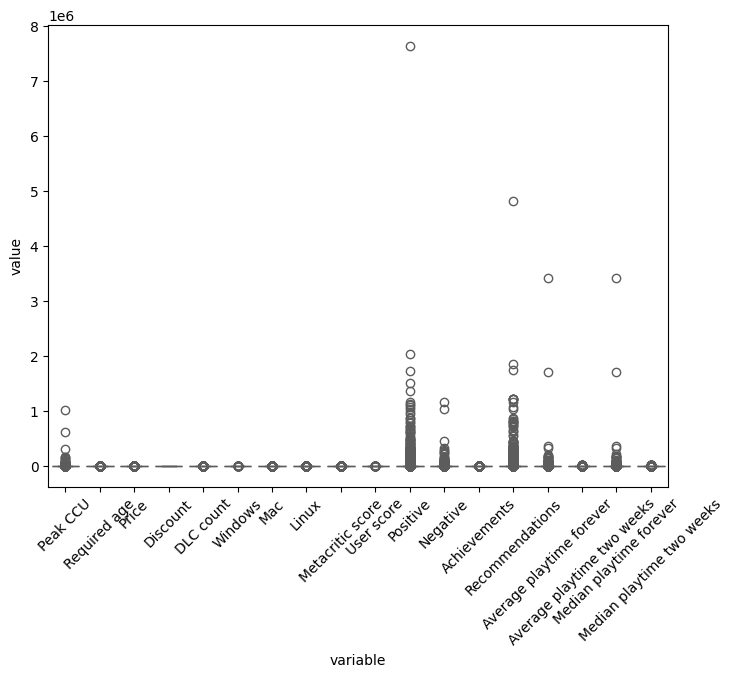

In [7]:
plt.rcParams['figure.figsize'] = (8, 6)
cols_num = df.select_dtypes(include=['int64', 'float64']).columns
df_melt = df[cols_num].melt()

sns.boxplot(data=df_melt, x='variable', y='value', hue='variable', 
            palette='hls', fill=True, legend=False)
plt.xticks(rotation=45)
plt.show()

L'analyse exploratoire initiale montre une hétérogénéité extrême des données. La présence d'outliers atteignant plusieurs millions d'unités (avis positifs) rend les variables de prix et de scores illisibles sur une échelle linéaire. Cela justifie le recours ultérieur à une transformation logarithmique et à une segmentation du dataset.

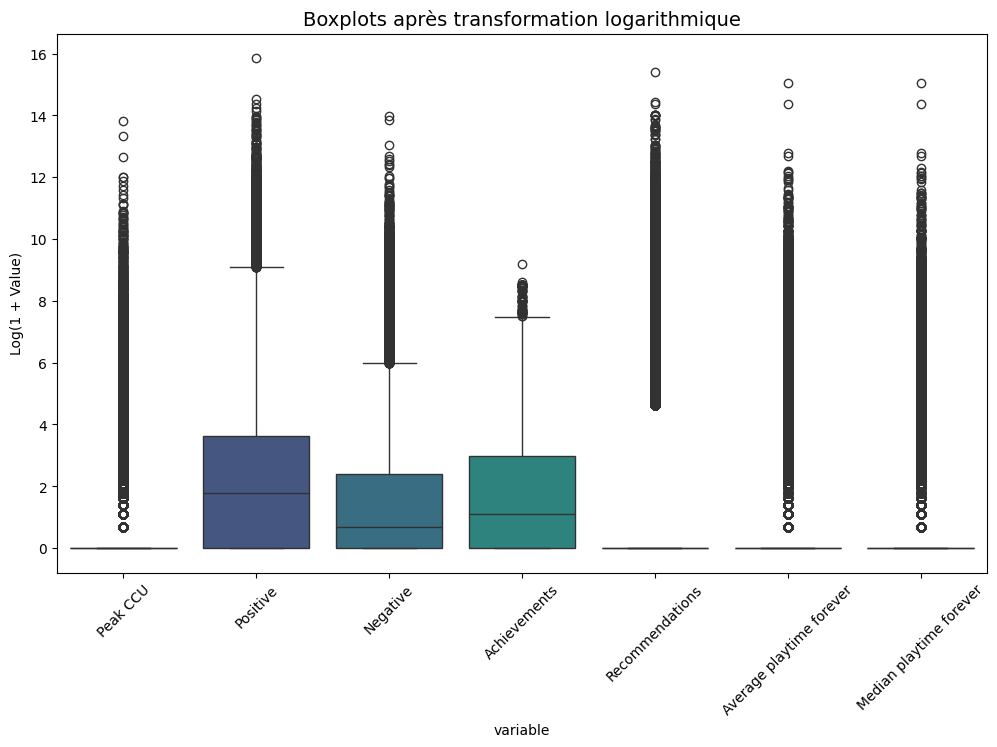

In [8]:
cols_to_log = ['Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations', 
               'Average playtime forever', 'Median playtime forever']

df_log = df.copy()
for col in cols_to_log:
    if col in df_log.columns:
        df_log[col] = np.log1p(df_log[col])

df_melted_log = df_log[cols_to_log].melt()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_melted_log, x='variable', y='value', hue='variable', 
            palette='viridis', fill=True, legend=False)

plt.xticks(rotation=45)
plt.ylabel("Log(1 + Value)")
plt.title("Boxplots après transformation logarithmique", fontsize=14)
plt.show()

La transformation logarithmique a permis de réduire l'asymétrie des données.

## Analyse multidimensionnelle

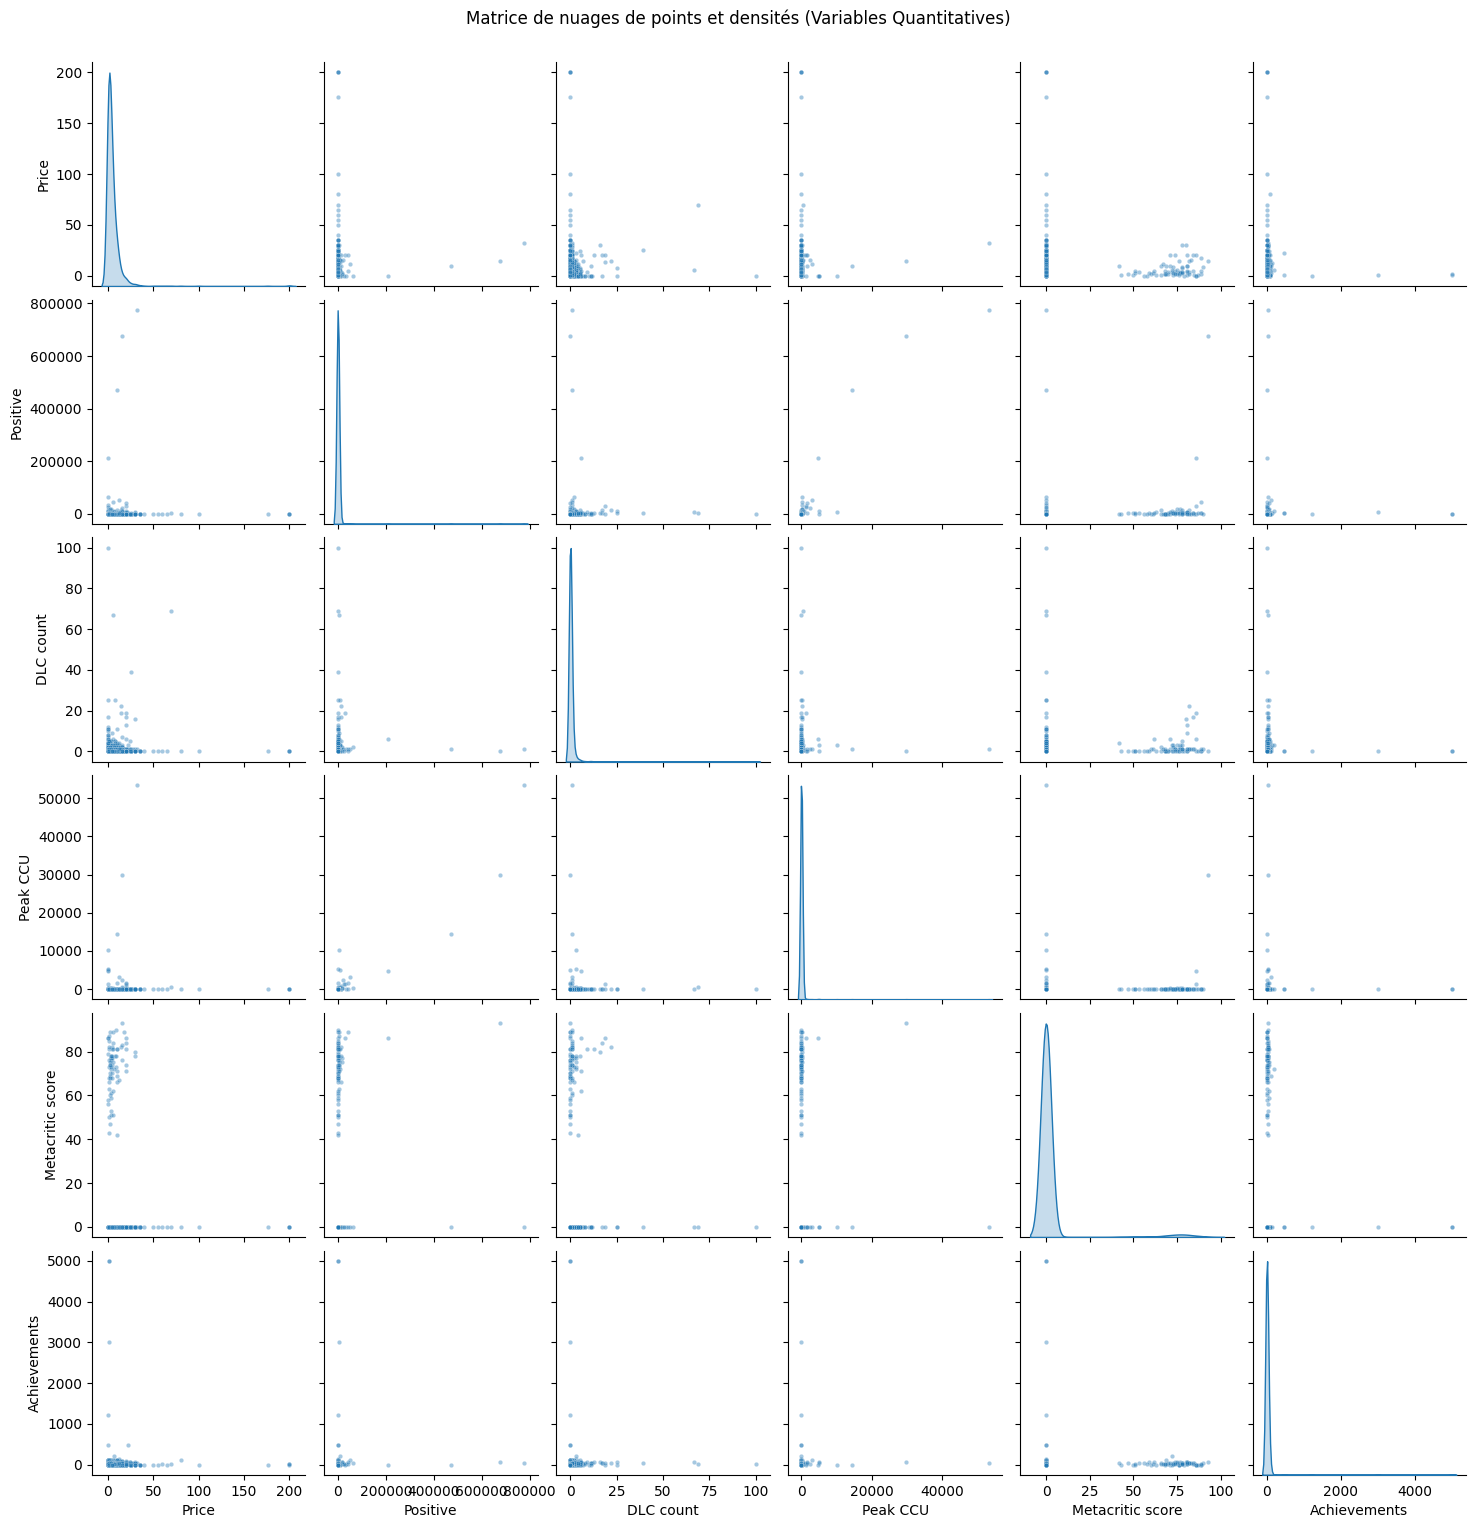

In [9]:
cols_quanti = [
    'Price', 'Positive', 'DLC count', 'Peak CCU', 
    'Metacritic score', 'Achievements'
]

data_quanti = df[[c for c in cols_quanti if c in df.columns]]

sns.pairplot(data_quanti.sample(min(2000, len(data_quanti))), 
             diag_kind='kde', 
             plot_kws={'alpha': 0.4, 's': 10})

plt.suptitle("Matrice de nuages de points et densités (Variables Quantitatives)", y=1.02)
plt.show()

La matrice de dispersion montre que les variables de succès (Positive, Peak CCU) sont corrélées entre elles, ce qui justifie une réduction de dimension via l'ACP. À l'inverse, le prix et les scores semblent apporter des informations orthogonales (indépendantes), ce qui enrichira la typologie des clusters.

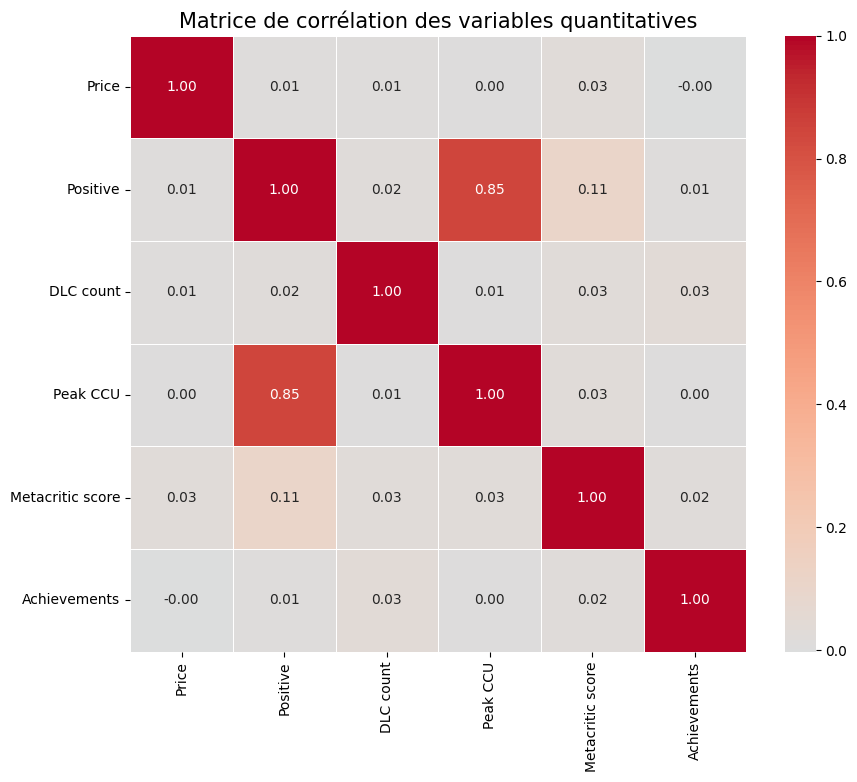

In [10]:

corr_matrix = data_quanti.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       
            fmt=".2f",        
            cmap='coolwarm',  
            center=0,         
            linewidths=0.5, 
            square=True)

plt.title("Matrice de corrélation des variables quantitatives", fontsize=15)
plt.show()

L'analyse des corrélations révèle une structure multidimensionnelle : un axe de succès très marqué (Positive/Peak CCU) et des axes indépendants comme le prix et la qualité critique. Cette absence de corrélation globale entre toutes les variables confirme l'intérêt d'une ACP pour identifier les typologies de jeux qui s'écartent de la norme.

## Analyse en composantes principales

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

cols_quanti = [
    'Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 
    'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 
    'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 
    'Median playtime forever', 'Median playtime two weeks'
]

cols_to_log = [
    'Peak CCU', 'Positive', 'Negative', 'Achievements', 'Recommendations', 
    'Average playtime forever', 'Median playtime forever'
]

data_pca = df[cols_quanti].apply(pd.to_numeric, errors='coerce').fillna(0)

for col in cols_to_log:
    data_pca[col] = np.log1p(data_pca[col])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pca)

pca = PCA()
pca_coords = pca.fit_transform(data_scaled)

eigenvalues = pca.explained_variance_
variance_ratio = pca.explained_variance_ratio_ * 100
cum_variance_ratio = np.cumsum(variance_ratio)

res_pca_eig = pd.DataFrame({
    'Eigenvalue': eigenvalues,
    'Percentage of variance': variance_ratio,
    'Cumulative percentage': cum_variance_ratio
}, index=[f"Dim.{i+1}" for i in range(len(eigenvalues))])

print("--- TABLEAU DES VALEURS PROPRES (Log partiel) ---")
print(res_pca_eig.round(3).head(10))


--- TABLEAU DES VALEURS PROPRES (Log partiel) ---
        Eigenvalue  Percentage of variance  Cumulative percentage
Dim.1        5.240                  34.931                 34.931
Dim.2        1.919                  12.792                 47.723
Dim.3        1.053                   7.017                 54.741
Dim.4        1.022                   6.812                 61.552
Dim.5        1.000                   6.668                 68.221
Dim.6        0.992                   6.615                 74.835
Dim.7        0.901                   6.004                 80.839
Dim.8        0.763                   5.089                 85.928
Dim.9        0.721                   4.807                 90.735
Dim.10       0.568                   3.785                 94.520


On va garder les 7 premières composantes principales car à elles, elles expliquent plus de 80% de la variance.

C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\3530685007.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='Dimension', y='Coordonnée', palette='Set3',


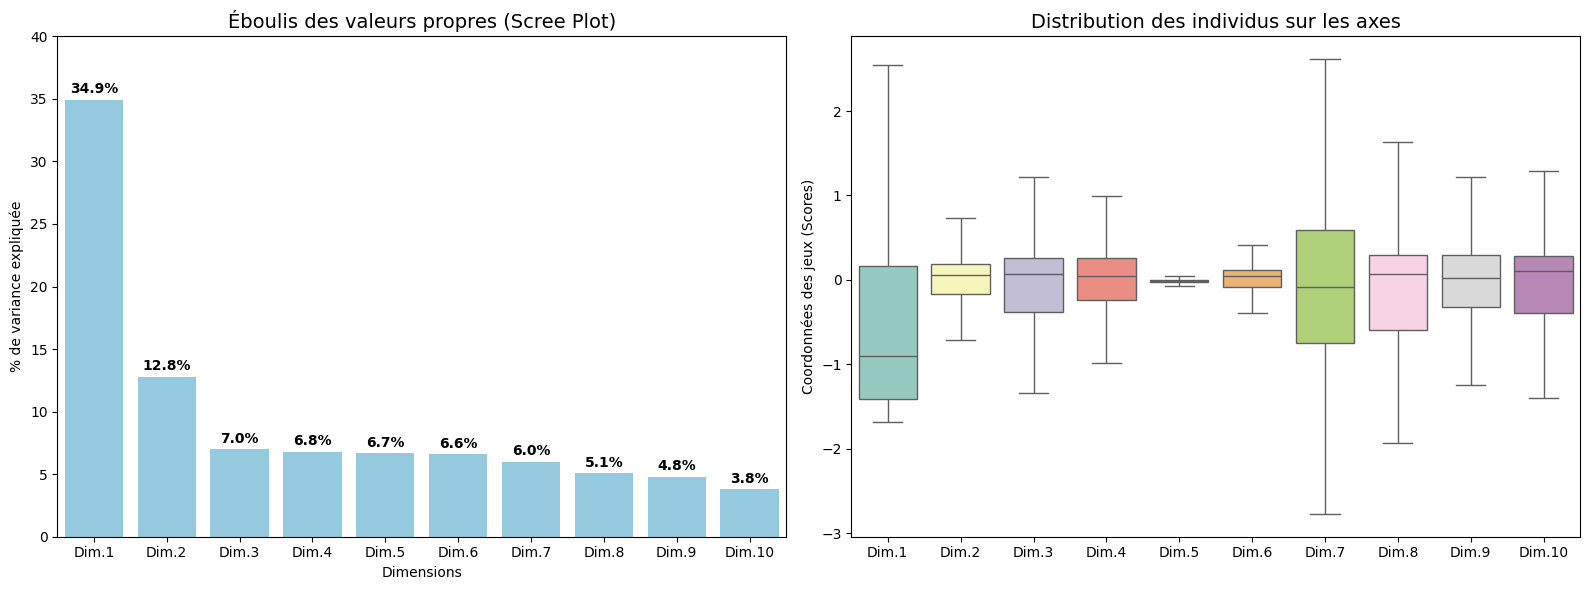

In [12]:
n_components = len(res_pca_eig)
dims = [f"Dim.{i+1}" for i in range(n_components)]

pca_data = pca.fit_transform(data_scaled)
df_coords = pd.DataFrame(pca_data, columns=dims)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

top_n = min(10, n_components)
sns.barplot(x=dims[:top_n], y=res_pca_eig['Percentage of variance'][:top_n], 
            color='skyblue', ax=ax1)

for i, v in enumerate(res_pca_eig['Percentage of variance'][:top_n]):
    ax1.text(i, v + 0.5, f"{v:.1f}%", ha='center', fontweight='bold')

ax1.set_ylim(0, 40)
ax1.set_title("Éboulis des valeurs propres (Scree Plot)", fontsize=14)
ax1.set_ylabel("% de variance expliquée")
ax1.set_xlabel("Dimensions")

df_melted = df_coords.iloc[:, :top_n].melt(var_name='Dimension', value_name='Coordonnée')

sns.boxplot(data=df_melted, x='Dimension', y='Coordonnée', palette='Set3', 
            ax=ax2, showfliers=False) 

ax2.set_title("Distribution des individus sur les axes", fontsize=14)
ax2.set_ylabel("Coordonnées des jeux (Scores)")
ax2.set_xlabel("")

plt.tight_layout()
plt.show()

On remarque que les deux premières dimensions portent près de 50% de l'information, on voit que le coude est présent entre la 2ème et 3ème dimension, on va pouvoir se concentrer sur le premier plan factoriel pour la suite des analyses


C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\1975197137.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('jet')


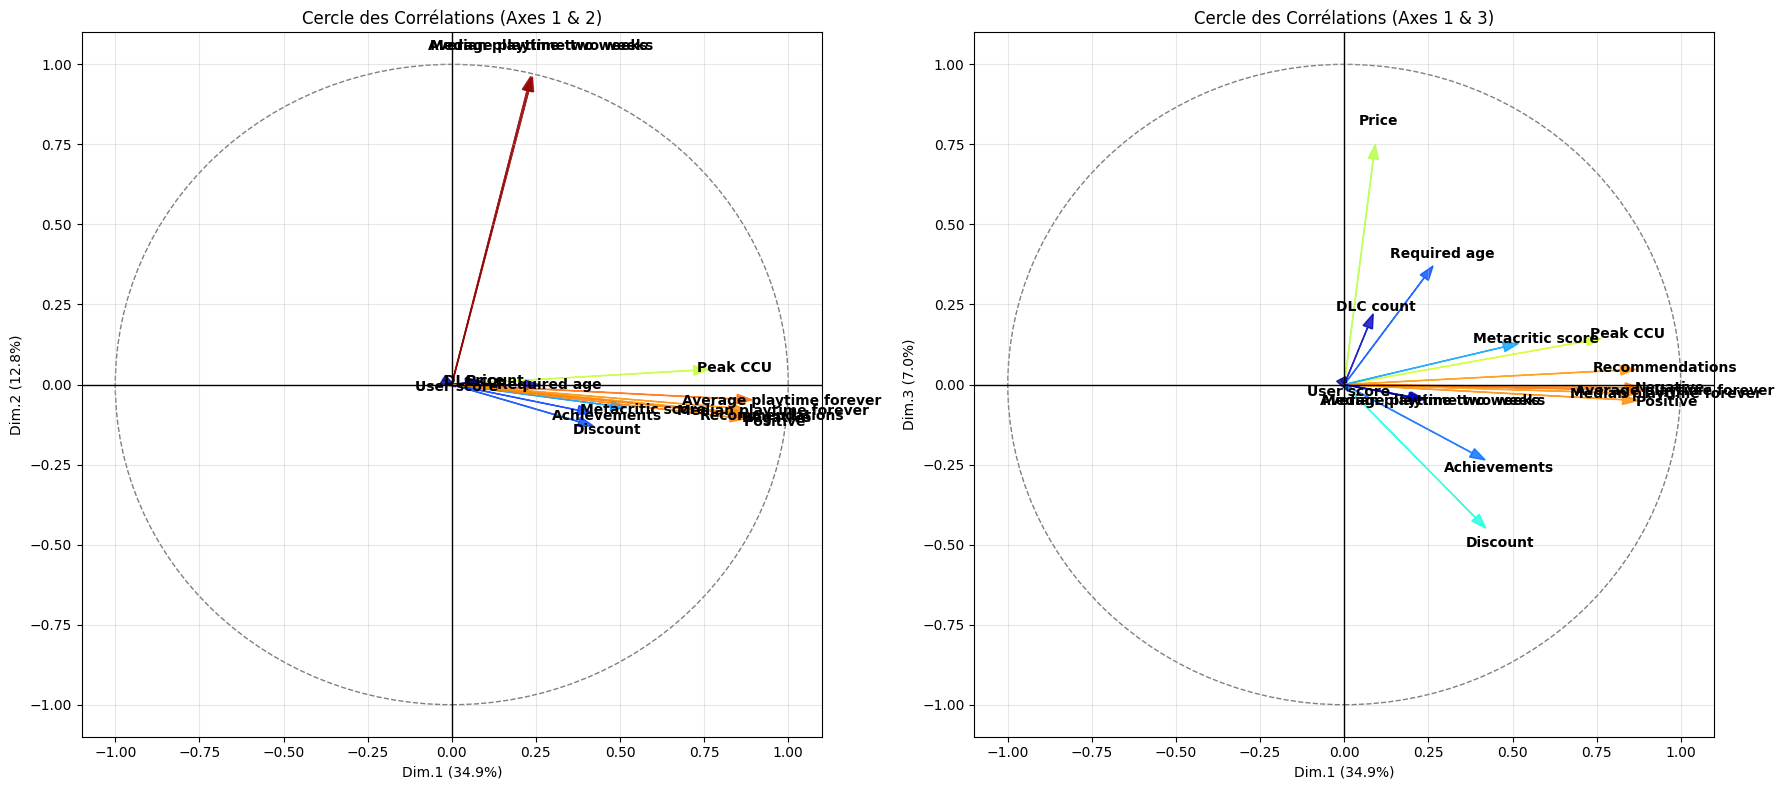

In [13]:
import matplotlib.cm as cm

def plot_circles_side_by_side(pca, features):
    
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    cos2 = loadings**2
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    

    axis_pairs = [(0, 1), (0, 2)]
    axes_objs = [ax1, ax2]
    
    for i, (ax, (dim_x, dim_y)) in enumerate(zip(axes_objs, axis_pairs)):
        
        circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
        ax.add_artist(circle)
        
        current_cos2 = cos2[:, dim_x] + cos2[:, dim_y]
        
        
        norm = plt.Normalize(vmin=0, vmax=1)
        cmap = cm.get_cmap('jet') 

        for j, feature in enumerate(features):
            x_coord = loadings[j, dim_x]
            y_coord = loadings[j, dim_y]
            color = cmap(norm(current_cos2[j]))
            
        
            ax.arrow(0, 0, x_coord, y_coord, color=color, alpha=0.8, 
                     head_width=0.03, length_includes_head=True)
            
            ax.text(x_coord*1.1, y_coord*1.1, feature, color='black', 
                    ha='center', va='center', fontsize=10, fontweight='bold')

        
        ax.set_xlim(-1.1, 1.1)
        ax.set_ylim(-1.1, 1.1)
        ax.axhline(0, color='black', lw=1)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel(f"Dim.{dim_x+1} ({pca.explained_variance_ratio_[dim_x]:.1%})")
        ax.set_ylabel(f"Dim.{dim_y+1} ({pca.explained_variance_ratio_[dim_y]:.1%})")
        ax.set_title(f"Cercle des Corrélations (Axes {dim_x+1} & {dim_y+1})")
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Utilisation
plot_circles_side_by_side(pca, cols_quanti)

C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\1869820704.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_contrib, x='Contribution', y='Variable',
C:\Users\eliot\AppData\Local\Temp\ipykernel_3848\1869820704.p

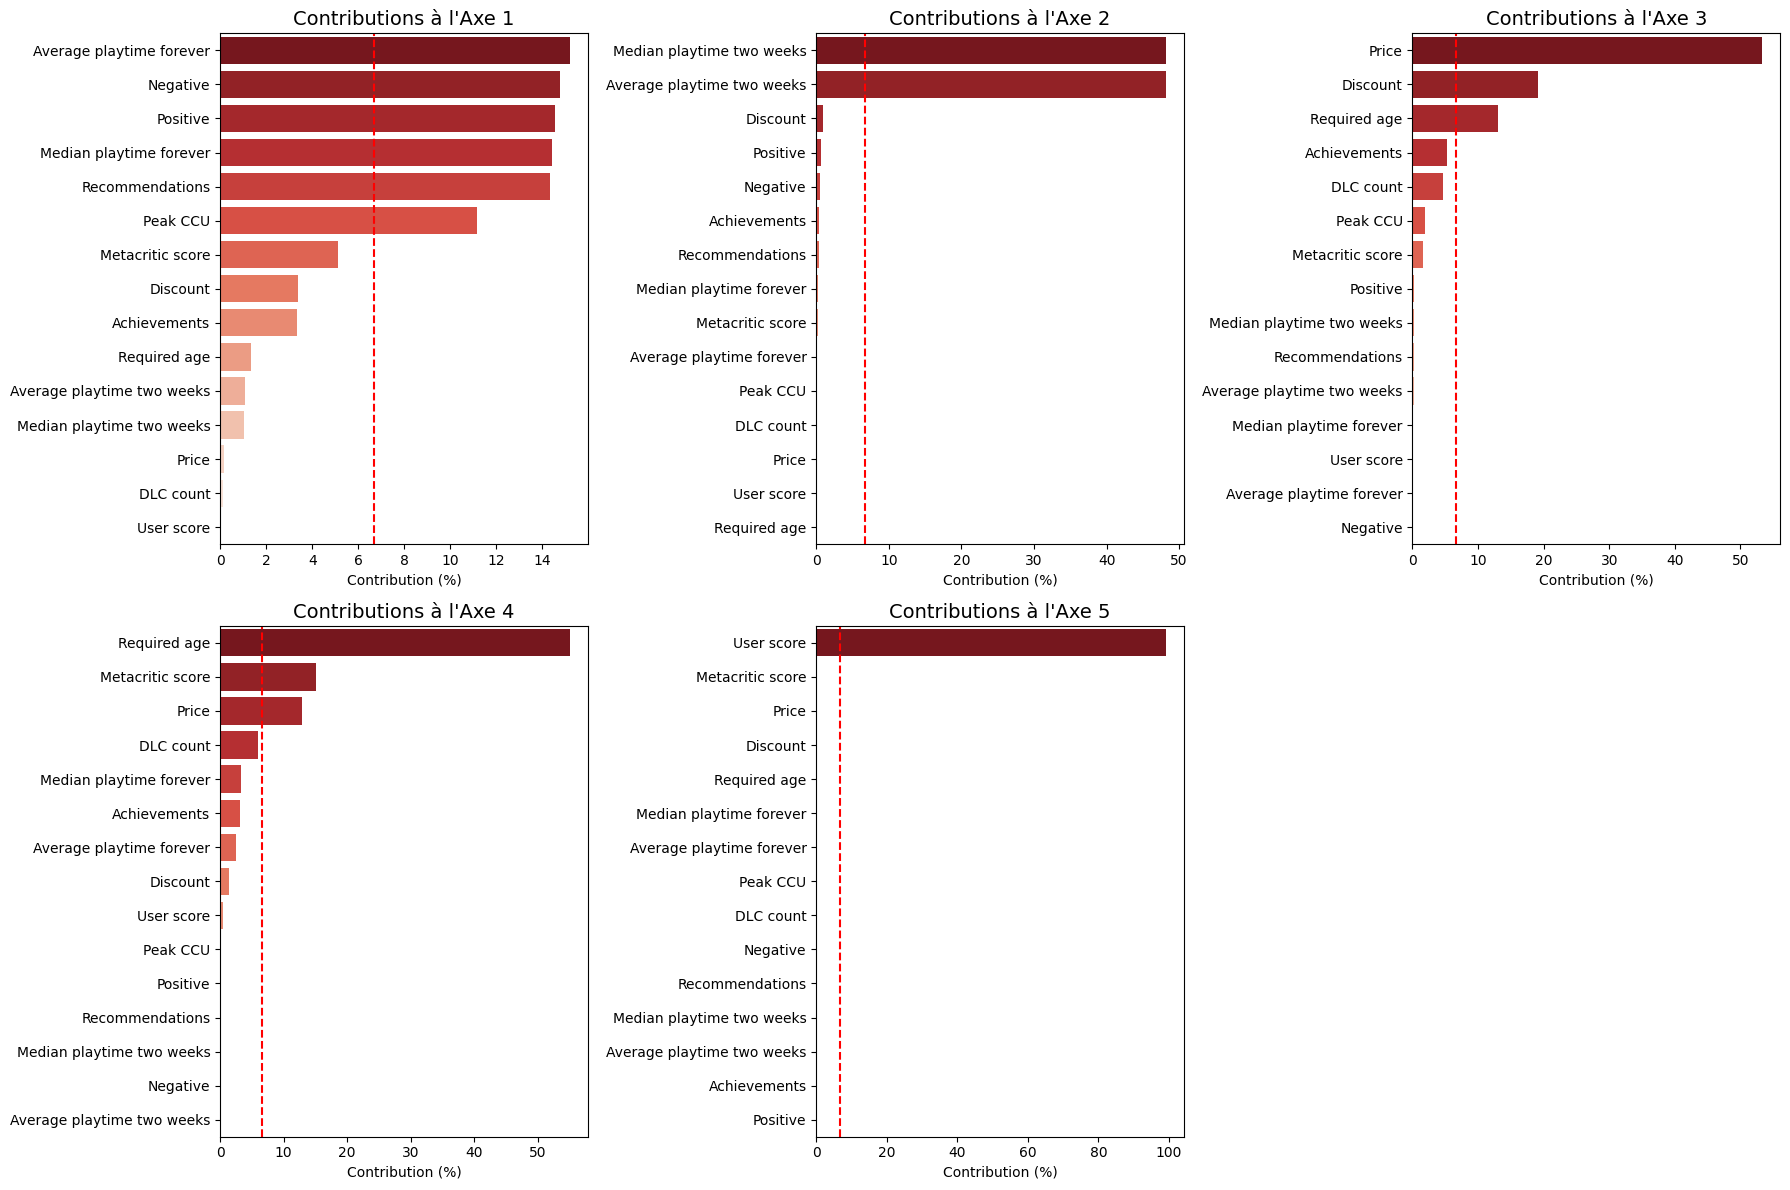

In [14]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = loadings**2
contributions = (cos2 / cos2.sum(axis=0)) * 100

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

seuil = 100 / len(cols_quanti)

for i in range(6):  
    df_contrib = pd.DataFrame({
        'Variable': cols_quanti,
        'Contribution': contributions[:, i]
    }).sort_values('Contribution', ascending=False)
    
    
    sns.barplot(data=df_contrib, x='Contribution', y='Variable', 
                palette='Reds_r', ax=axes[i])
    

    axes[i].axvline(seuil, color='red', linestyle='--', label='Seuil moyen')
    
    axes[i].set_title(f"Contributions à l'Axe {i+1}", fontsize=14)
    axes[i].set_xlabel("Contribution (%)")
    axes[i].set_ylabel("")

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

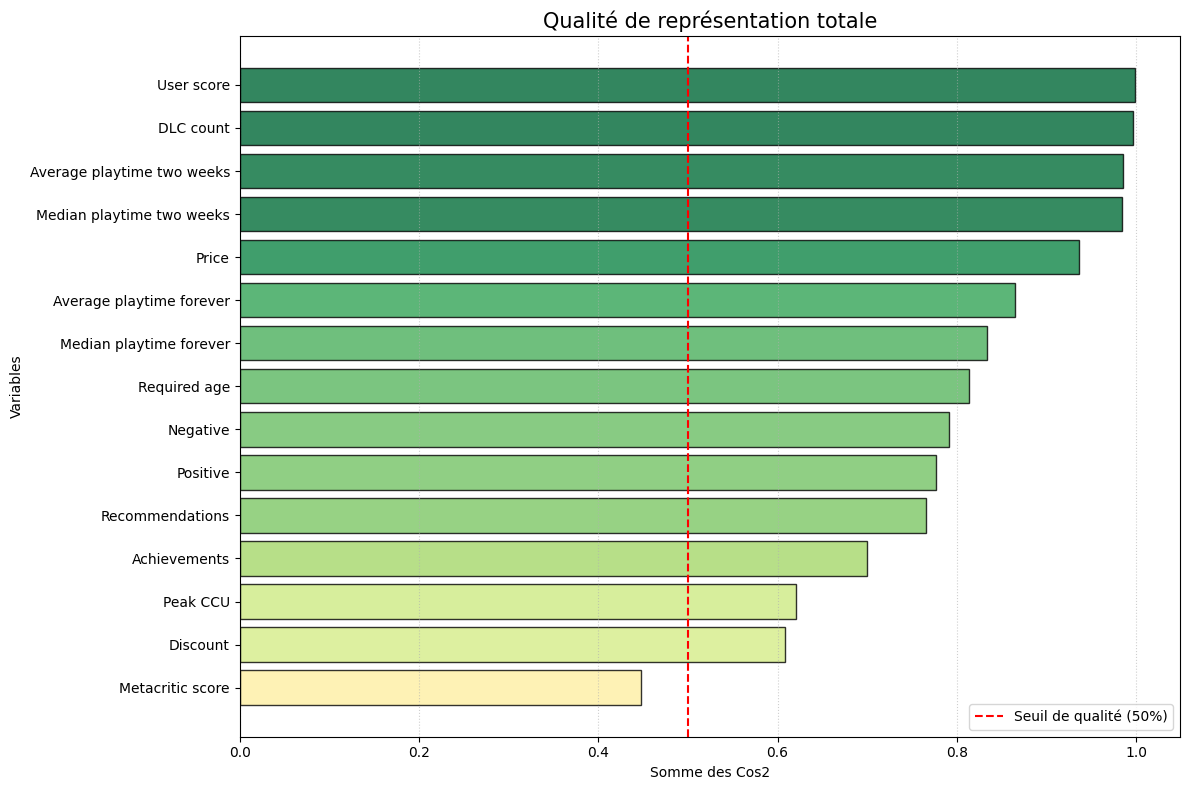

In [15]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = loadings**2

var_cos2_sum = cos2[:, :7].sum(axis=1)

df_cos2 = pd.DataFrame({
    'Variable': cols_quanti,
    'Cos2_Total': var_cos2_sum
}).sort_values('Cos2_Total')

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn(df_cos2['Cos2_Total']) 

plt.barh(df_cos2['Variable'], df_cos2['Cos2_Total'], color=colors, edgecolor='black', alpha=0.8)

plt.axvline(0.5, color='red', linestyle='--', label='Seuil de qualité (50%)')


plt.title("Qualité de représentation totale", fontsize=15)
plt.xlabel("Somme des Cos2")
plt.ylabel("Variables")
plt.legend()
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

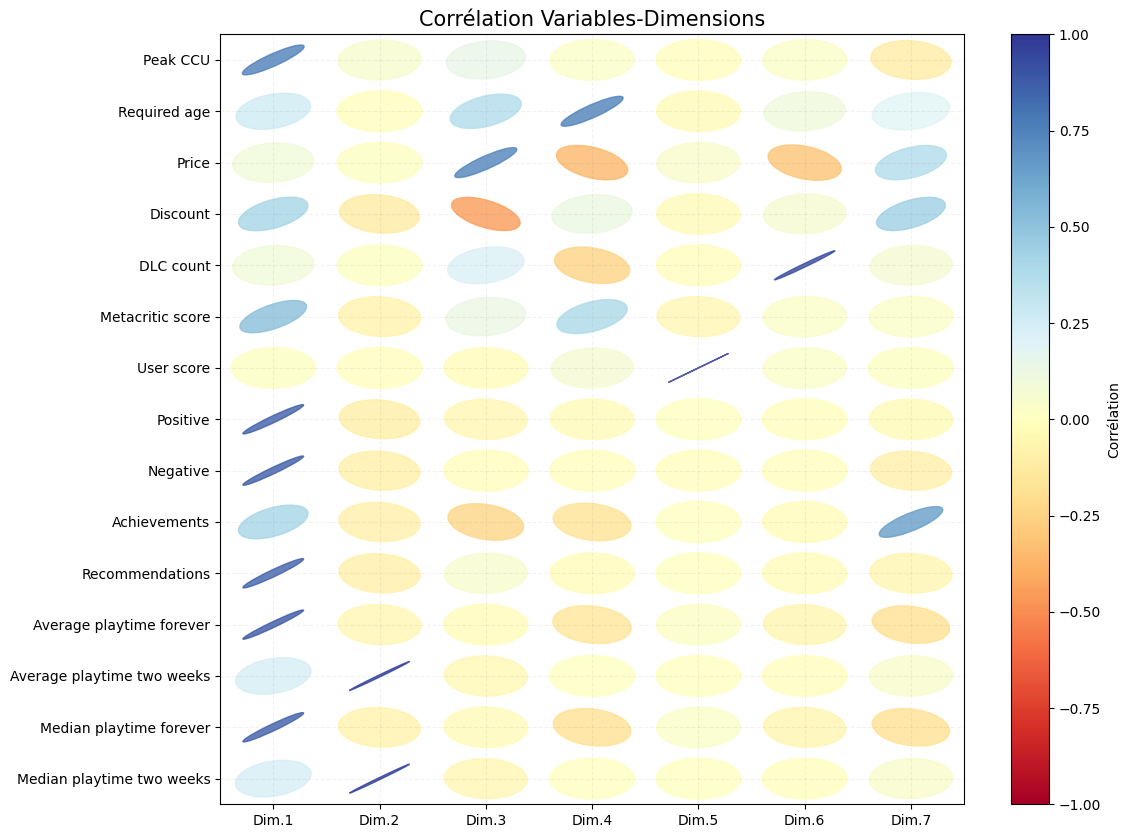

In [16]:
from matplotlib.patches import Ellipse

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
df_loadings = pd.DataFrame(loadings, index=cols_quanti, 
                           columns=[f'Dim.{i+1}' for i in range(len(eigenvalues))])

df_loadings_top = df_loadings.iloc[:, :7]

def plot_corr_ellipses(df, title="Corrélation Variables-Dimensions"):
    plt.figure(figsize=(12, 10))
    ax = plt.gca()
    
    n_rows, n_cols = df.shape
    for i in range(n_rows):
        for j in range(n_cols):
            corr = df.iloc[i, j]
            color = plt.cm.RdYlBu((corr + 1) / 2)
            width = 1.0 - abs(corr)
            ellipse = Ellipse(xy=(j, n_rows-1-i), width=0.8, height=0.8*width, 
                              angle=np.sign(corr)*45 if abs(corr) > 0.01 else 0,
                              color=color, alpha=0.8)
            ax.add_patch(ellipse)
            
    plt.xticks(range(n_cols), df.columns)
    plt.yticks(range(n_rows), reversed(df.index))
    plt.title(title, fontsize=15)
    plt.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(-1, 1), cmap='RdYlBu'), ax=ax, label='Corrélation')
    
    plt.xlim(-0.5, n_cols - 0.5)
    plt.ylim(-0.5, n_rows - 0.5)
    plt.grid(visible=True, color='gray', linestyle='--', alpha=0.1)
    plt.show()

plot_corr_ellipses(df_loadings_top)

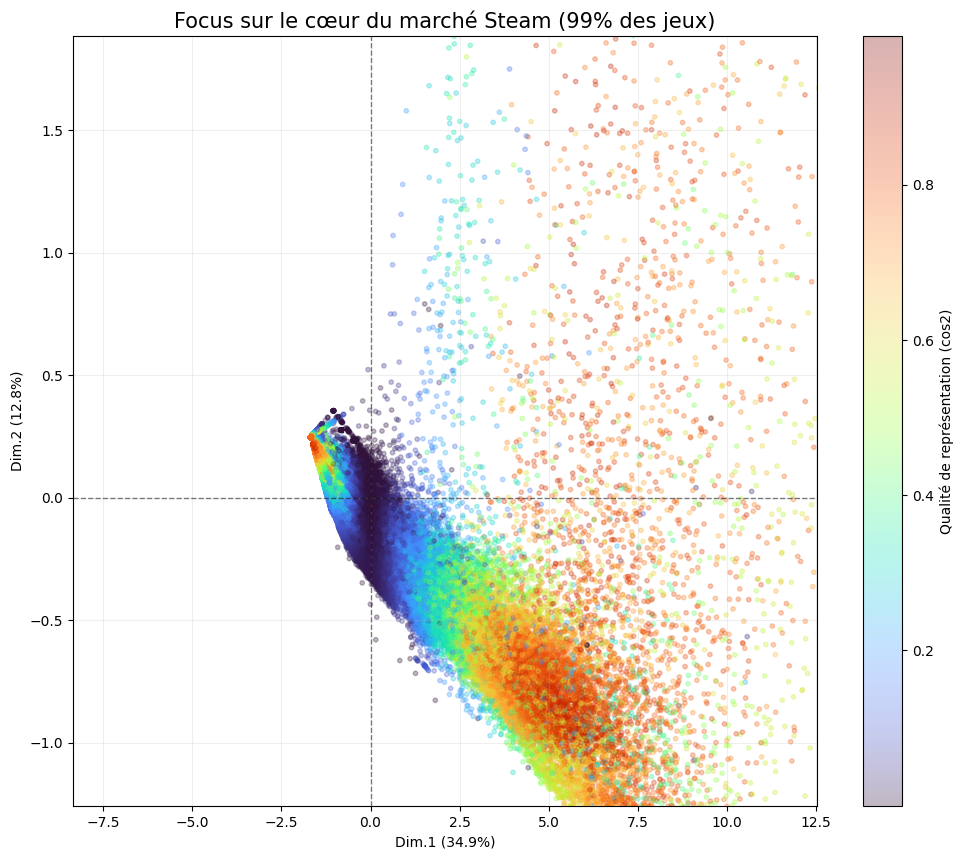

In [17]:
ind_coords = pca_data[:, :2] 
ind_dist2 = (data_scaled**2).sum(axis=1) 
cos2_ind = (ind_coords**2).sum(axis=1) / ind_dist2

x_limit = np.percentile(np.abs(ind_coords[:, 0]), 99)
y_limit = np.percentile(np.abs(ind_coords[:, 1]), 99)

plt.figure(figsize=(12, 10))

scatter = plt.scatter(ind_coords[:, 0], ind_coords[:, 1], 
                      c=cos2_ind, 
                      cmap='turbo', 
                      alpha=0.3, 
                      s=10)

plt.xlim(-x_limit, x_limit * 1.5) 
plt.ylim(-y_limit, y_limit * 1.5)


plt.colorbar(scatter, label='Qualité de représentation (cos2)')
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel(f"Dim.1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"Dim.2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("Focus sur le cœur du marché Steam (99% des jeux)", fontsize=15)

plt.grid(alpha=0.2)
plt.show()

## Clustering

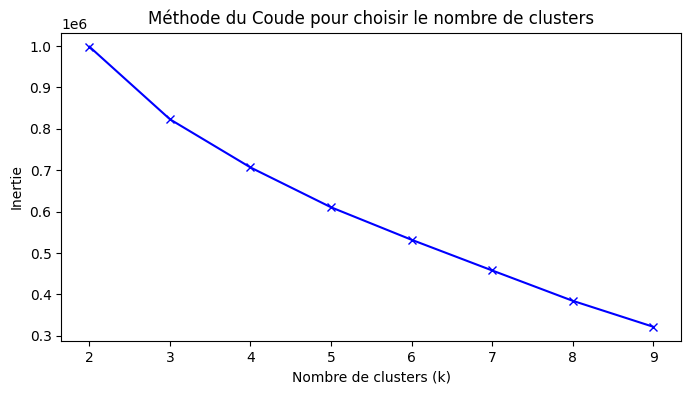

In [18]:
from sklearn.cluster import KMeans

pca_features = pca_coords[:, :7]

inertias = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(pca_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du Coude pour choisir le nombre de clusters')
plt.show()

Il n'y a pas de coude apparent, on va donc utiliser le diagramme silhouette.

Pour k=2, Silhouette Score = 0.6236
Pour k=3, Silhouette Score = 0.6215
Pour k=4, Silhouette Score = 0.3915
Pour k=5, Silhouette Score = 0.4002
Pour k=6, Silhouette Score = 0.4029


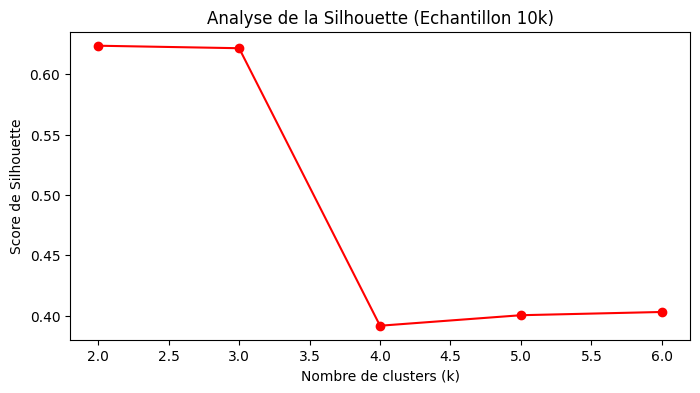

In [19]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df_sample = pd.DataFrame(pca_features).sample(n=10000, random_state=42).values

silhouettes = []
k_range = range(2, 7) 

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_features)
    
    km_sample = KMeans(n_clusters=k, random_state=42, n_init=10)
    sample_labels = km_sample.fit_predict(df_sample)
    score = silhouette_score(df_sample, sample_labels)
    silhouettes.append(score)
    print(f"Pour k={k}, Silhouette Score = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette')
plt.title('Analyse de la Silhouette (Echantillon 10k)')
plt.show()

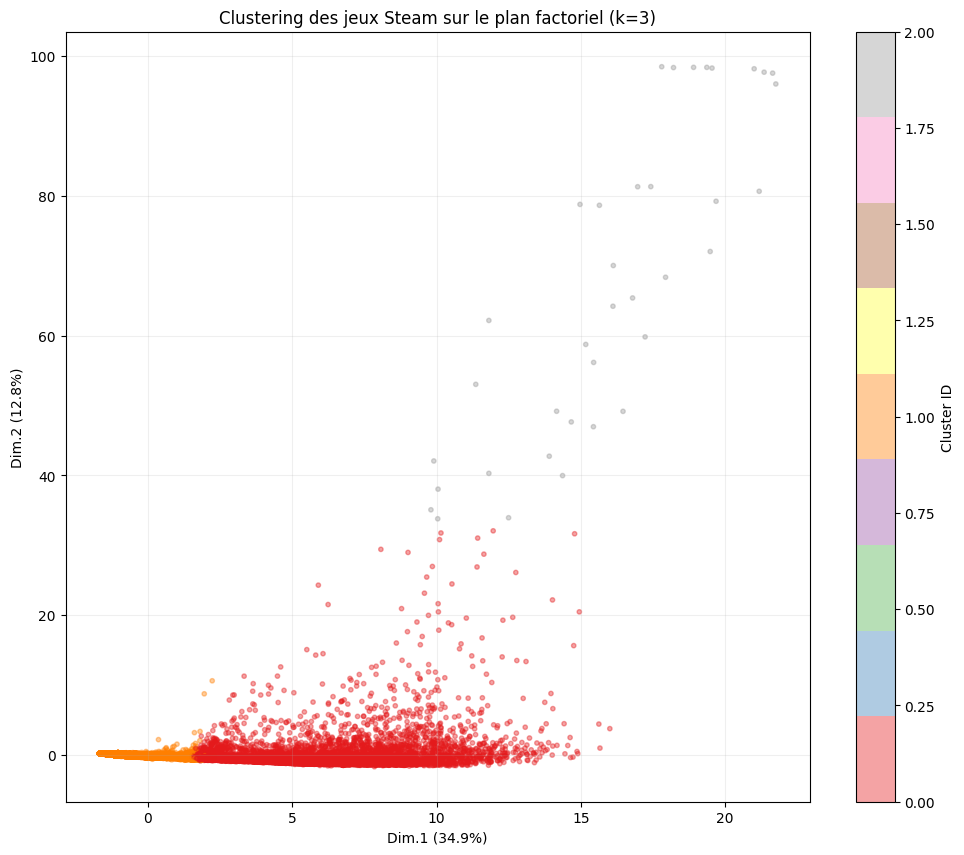

In [20]:
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features)

df['Cluster'] = clusters

plt.figure(figsize=(12, 10))
scatter = plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
                      c=clusters, cmap='Set1', alpha=0.4, s=10)

plt.xlabel(f"Dim.1 ({variance_ratio[0]:.1f}%)")
plt.ylabel(f"Dim.2 ({variance_ratio[1]:.1f}%)")
plt.title(f"Clustering des jeux Steam sur le plan factoriel (k={k_optimal})")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(alpha=0.2)
plt.show()

# Choses à faire: 

Analyse et Interprétation (ACP & Clustering)
Commenter l'éboulis des valeurs propres : Justifier le nombre d'axes retenus (règle de Kaiser ou du coude).

Interpréter les axes latents : Nommer la Dim 1 (Audience/Notoriété) et la Dim 2 (Engagement/Modèle économique) en fonction des contributions.

Commenter le cercle des corrélations : Analyser les angles entre les flèches (ex: corrélation entre prix et succès).

Identifier les outliers : Citer les jeux qui saturent les axes sur ton graphique d'individus (Image 3).

Caractériser les clusters : Décrire chaque groupe par ses moyennes (ex: "Cluster 1 = Jeux gratuits à fort engagement").

Nommer les "Parangons" : Lister 3 à 5 jeux réels représentatifs de chaque cluster.

2. Analyse des variables qualitatives (MCA / ACM)
Préparer les données : Transformer les colonnes textuelles (Genres, Catégories) en variables binaires ou indicatrices.

Lancer la MCA : Étudier les relations entre les genres déclarés (Action, RPG, Indie, etc.).

Croiser Genres et Clusters : Vérifier si les genres "Indie" ou "AAA" se superposent aux clusters statistiques.

3. Analyse Factorielle des Correspondances (AFC)
Tableau de contingence : Croiser deux variables qualitatives (ex: Genre vs Cluster ou Genre vs Année de sortie).

Visualiser l'AFC : Voir quelles catégories s'attirent ou se repoussent (ex: les jeux de Stratégie sont-ils plus présents dans le cluster "Hardcore" ?).

4. Synthèse Finale
Répondre à la problématique : Conclure sur l'existence de segments de marché distincts sur Steam.

Valider la cohérence : Comparer la vision "Développeurs" (Genres) avec la vision "Statistique" (Clusters).

Impact du temps : Commenter l'évolution de la structure du marché selon l'année de sortie (optionnel).